In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
movies_df = pd.read_csv(
    "../3.outputs/movies_processed.csv"
)

ratings_df = pd.read_csv(
    "../3.outputs/ratings_processed_main.csv",
    parse_dates=['rating_date']
)

tags_df = pd.read_csv(
    "../3.outputs/tags_processed.csv",
    parse_dates=['tag_date']
)

## 1. Univariate Analysis

In [3]:
movies_graph_df = movies_df[movies_df['release_year'] != -1]

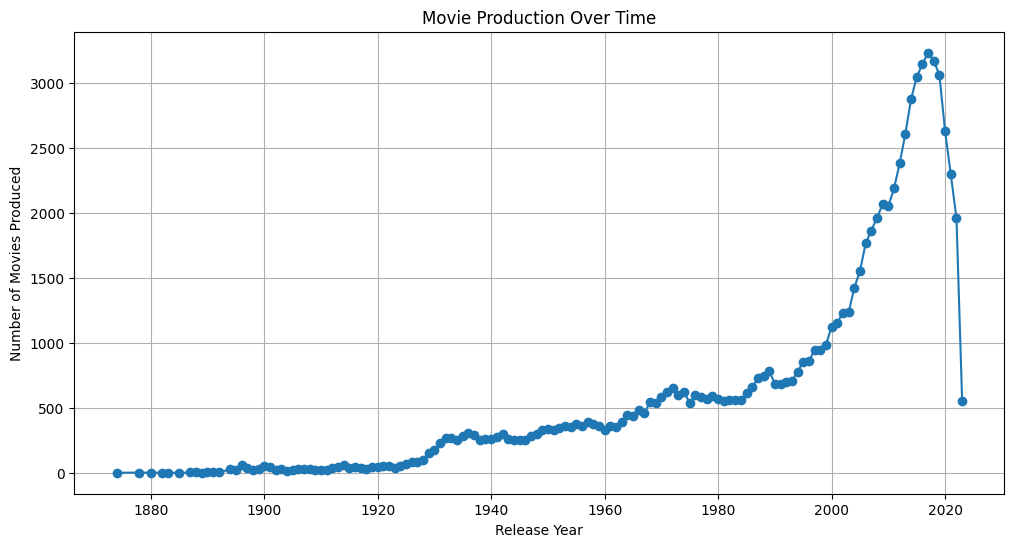

In [4]:
# Count movies released each year
movies_per_year = (
    movies_graph_df.groupby('release_year')
    .size()
)
# Create line plot
plt.figure(figsize=(12,6))
plt.plot(
    movies_per_year.index,
    movies_per_year.values,
    marker='o'
)
# Labels and title
plt.title('Movie Production Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies Produced')
# Grid for better readability
plt.grid(True)

# Show plot
plt.show()

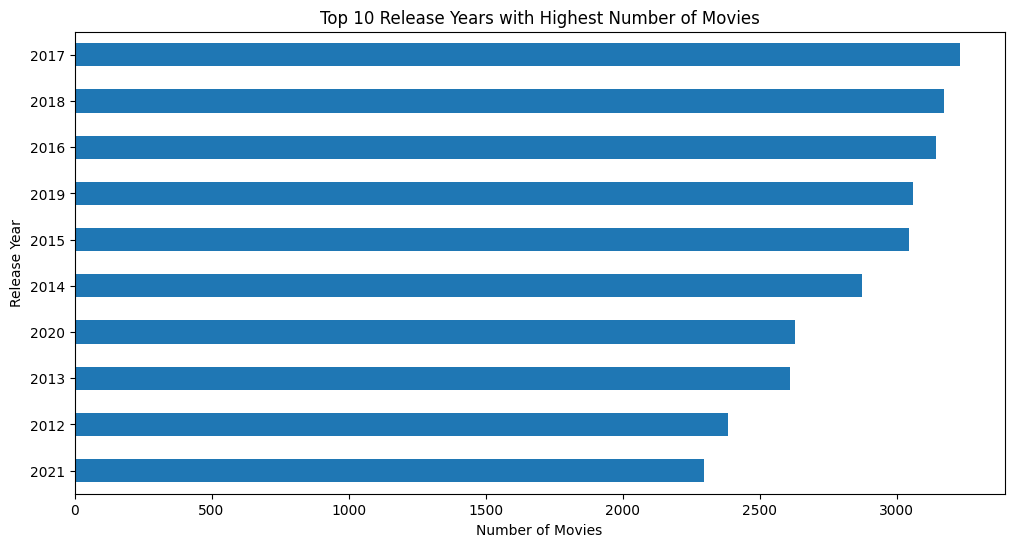

In [5]:
movies_per_year = (movies_graph_df.groupby('release_year').size().sort_values(ascending=False)
                   )
## Top 10 year with highest movie release 
top_years = movies_per_year.head(10)
plt.figure(figsize=(12,6))

top_years.sort_values().plot(kind='barh')

plt.title('Top 10 Release Years with Highest Number of Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Release Year')

plt.show()


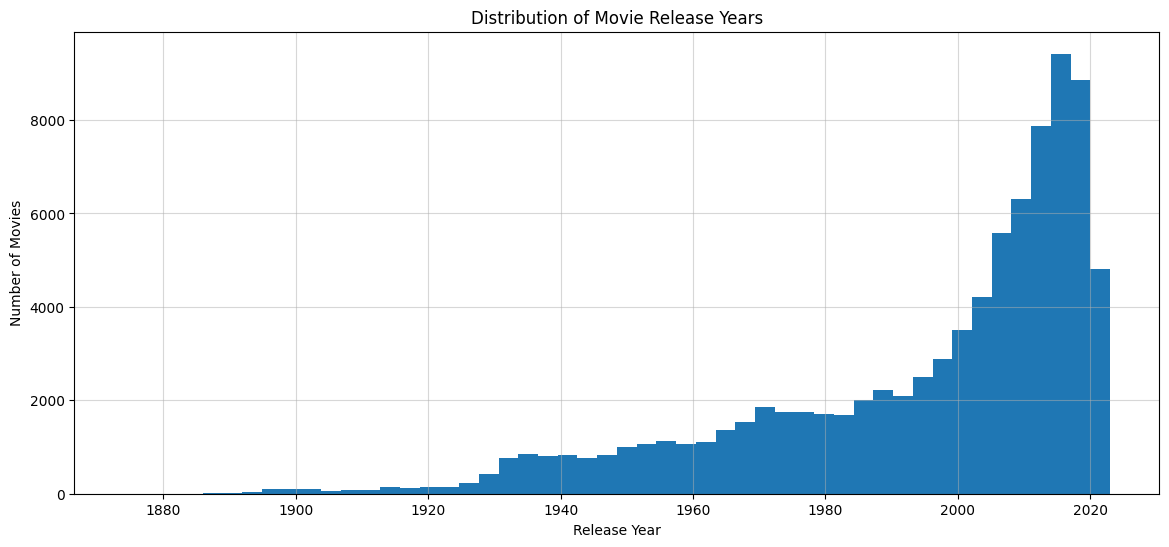

In [6]:
# What is the distribution of movie release years?
import matplotlib.pyplot as plt

# Remove invalid years
clean_movies_df = movies_df[
    movies_df['release_year'] > 1800
]
plt.figure(figsize=(14,6))

plt.hist(
    clean_movies_df['release_year'],
    bins=50
)
plt.title('Distribution of Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.grid(alpha=0.5)
plt.show()

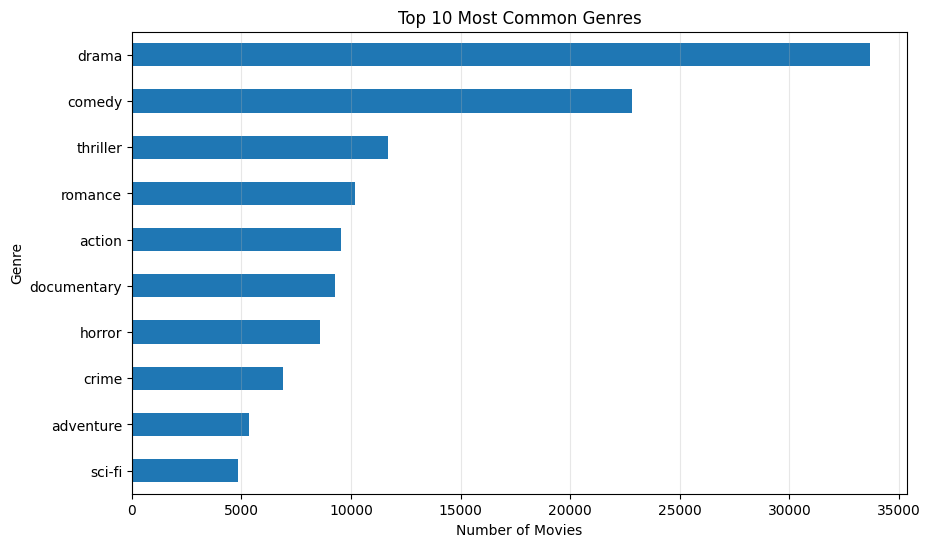

In [7]:
# Which genres are most common in the dataset?
preprocessed_movies = movies_df[movies_df['genres'] != 'unknown']
genres_distribution = preprocessed_movies['genres'].str.split(',').explode().value_counts()
plt.figure(figsize=(10,6))
genres_distribution.head(10).sort_values().plot(kind='barh')
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.grid(axis='x', alpha=0.3)
plt.show()


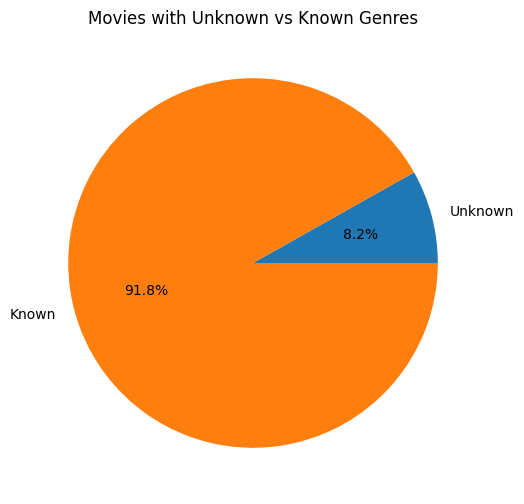

In [8]:
unknown_genres_count = (movies_df['genres']=='unknown').sum()
genre_labels = ['Unknown', 'Known']
genre_counts = [
    unknown_genres_count,
    len(movies_df) - unknown_genres_count
]
plt.figure(figsize=(6,6))
plt.pie(
    genre_counts,
    labels=genre_labels,
    autopct='%1.1f%%'
)

plt.title('Movies with Unknown vs Known Genres')

plt.show()

## RATINGS ANALYSIS

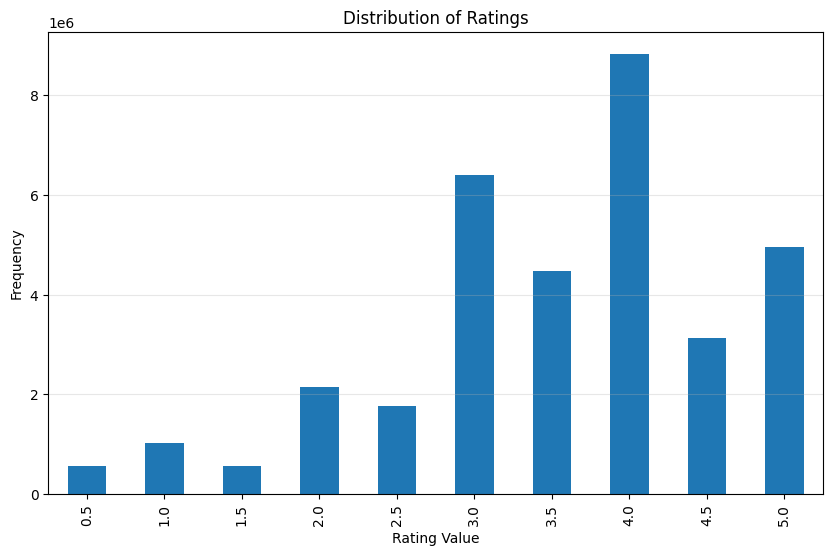

In [9]:
# How are ratings distributed across the dataset?
rating_distribution = (ratings_df['rating'].value_counts().sort_index())
plt.figure(figsize=(10,6))
rating_distribution.plot(kind='bar')
plt.title('Distribution of Ratings')
plt.xlabel('Rating Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

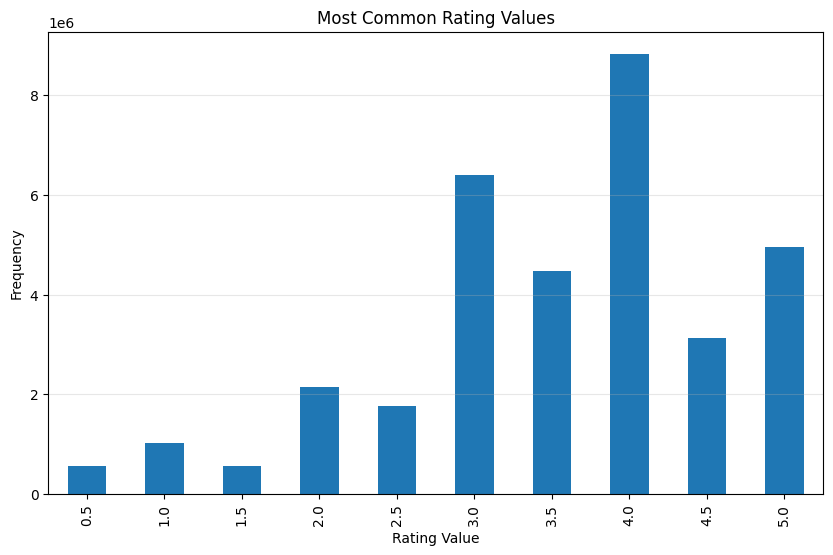

In [10]:
# Count frequency of each rating value
rating_distribution = (
    ratings_df['rating']
    .value_counts()
    .sort_index()
)
plt.figure(figsize=(10,6))

rating_distribution.plot(
    kind='bar'
)

# Labels and title
plt.title('Most Common Rating Values')
plt.xlabel('Rating Value')
plt.ylabel('Frequency')

# Grid
plt.grid(axis='y', alpha=0.3)

plt.show()

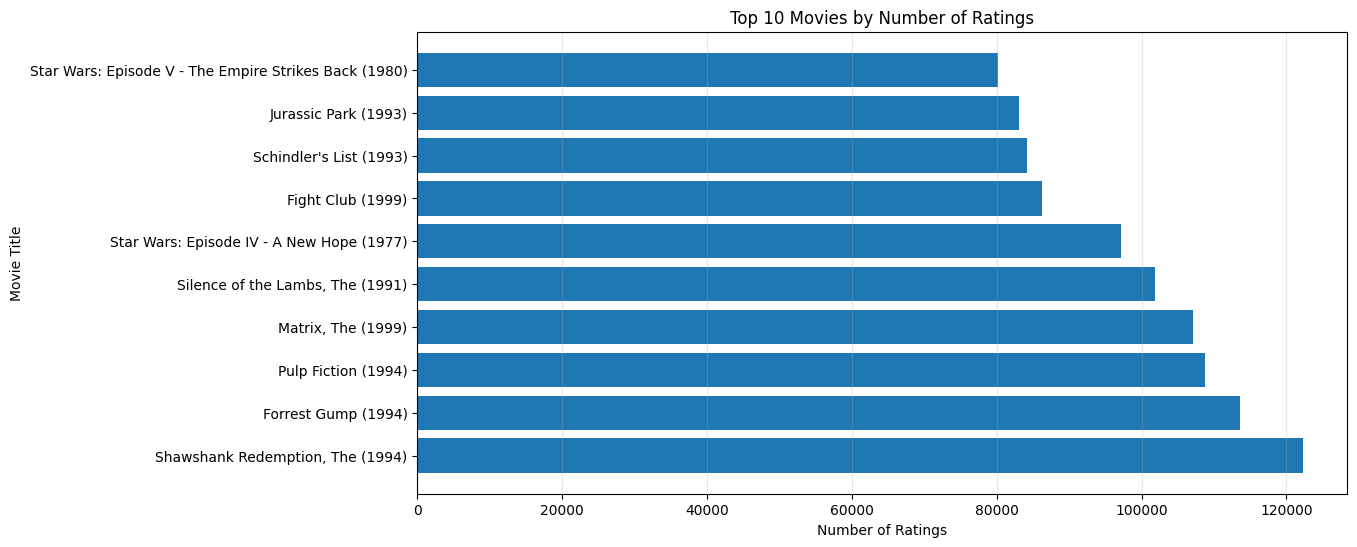

In [11]:
# Count ratings for each movie
movie_rating_counts = (
    ratings_df.groupby('movieid')
    .size()
    .reset_index(name='rating_count')
)
movie_rating_counts = movie_rating_counts.merge(
    movies_df[['movieid', 'title']],
    on='movieid'
)
top_movies = movie_rating_counts.sort_values(
                by='rating_count',
                ascending= False
                ).head(10)
plt.figure(figsize=(12,6))
plt.barh(
    top_movies['title'],
    top_movies['rating_count']
)
plt.title('Top 10 Movies by Number of Ratings')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.grid(axis='x', alpha=0.3)
plt.show()

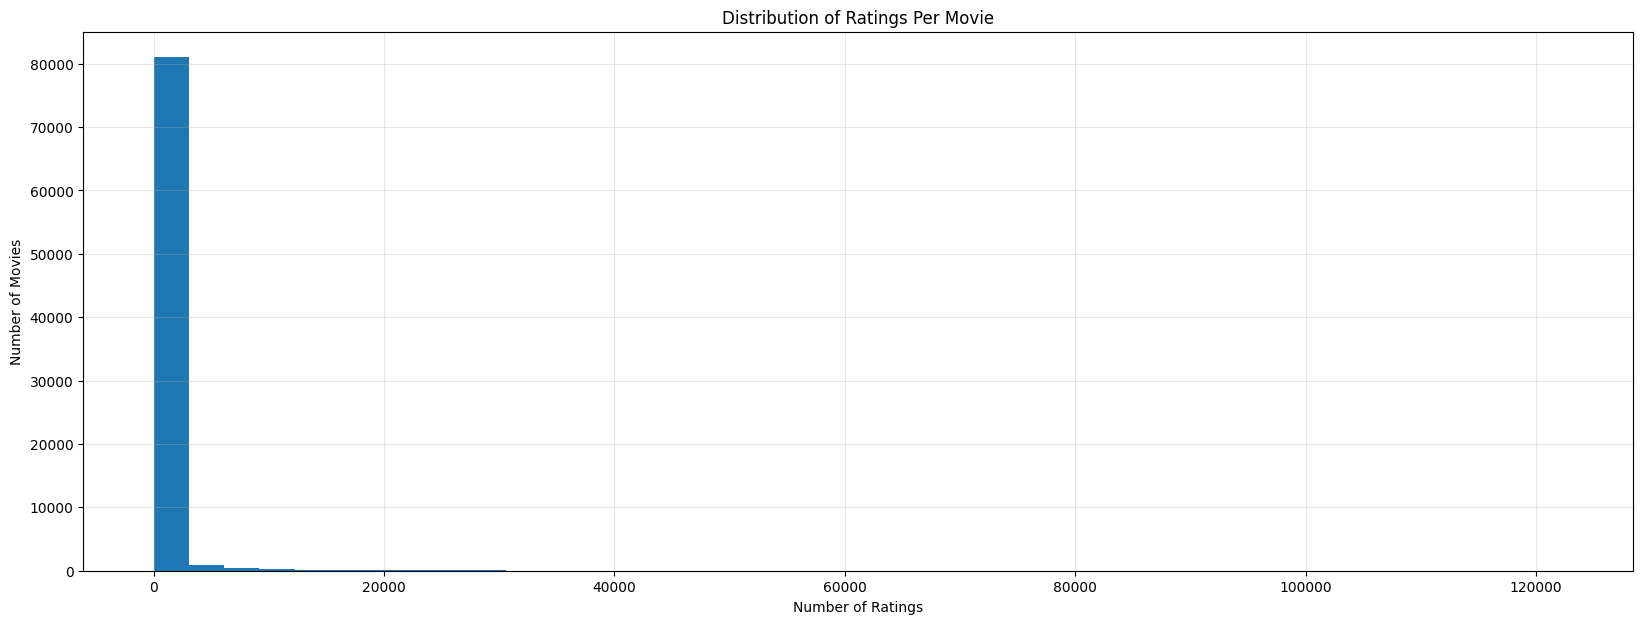

In [12]:
# How many ratings does each movie receive?
# Count ratings received by each movie
movie_rating_counts = (
    ratings_df.groupby('movieid')
    .size()
)

# Plot histogram
plt.figure(figsize=(20,7))

plt.hist(
    movie_rating_counts,
    bins=40
)
# Labels and title
plt.title('Distribution of Ratings Per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
# Grid
plt.grid(alpha=0.3)
plt.show()

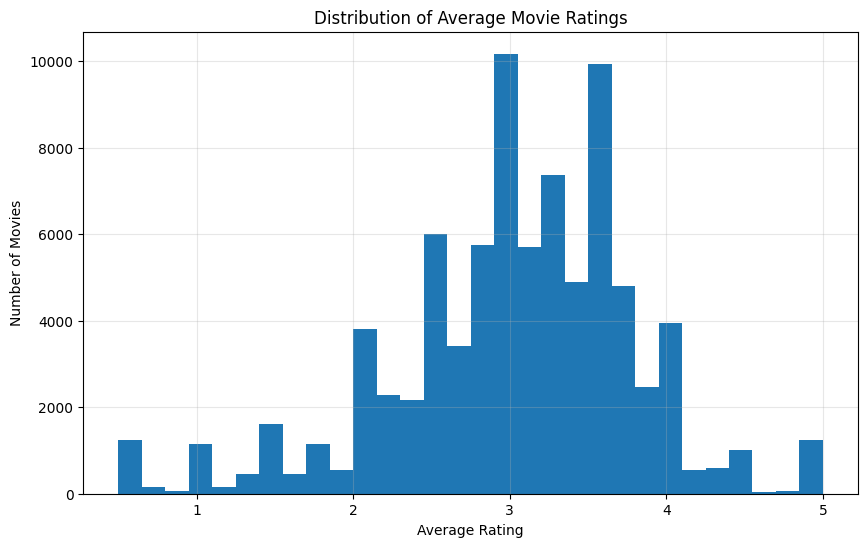

In [13]:
# Calculate average rating for each movie
average_movie_ratings = (
    ratings_df.groupby('movieid')['rating']
    .mean()
)

# Plot histogram
plt.figure(figsize=(10,6))
plt.hist(
    average_movie_ratings,
    bins=30
)
# Labels and title
plt.title('Distribution of Average Movie Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
# Grid
plt.grid(alpha=0.3)
plt.show()

## USER ANALYSIS

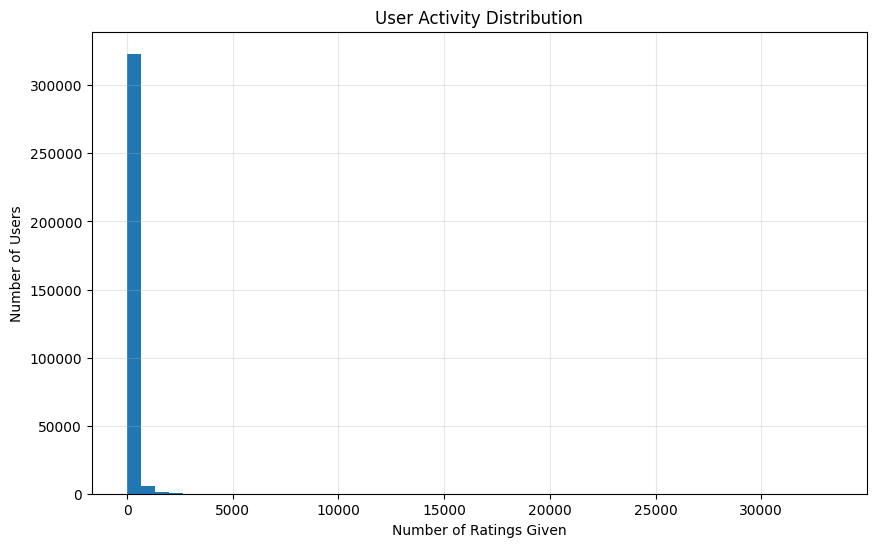

In [14]:
# Ratings count per user
user_rating_counts = ( ratings_df.groupby('userid').size())
plt.figure(figsize=(10,6))
plt.hist(
    user_rating_counts,
    bins = 50)
plt.title('User Activity Distribution')
plt.xlabel('Number of Ratings Given')
plt.ylabel('Number of Users')
plt.grid(alpha=0.3)
plt.show()

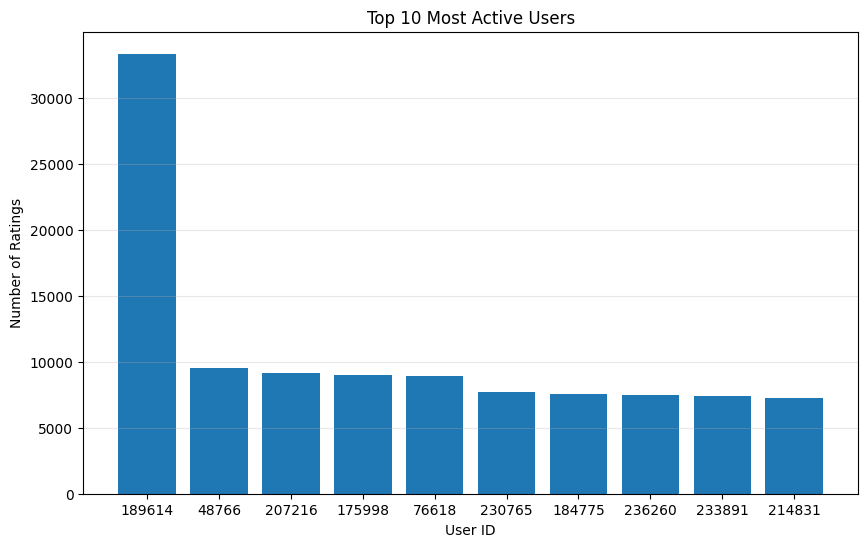

In [15]:
# Top active users
top_users = (
    ratings_df.groupby('userid')
    .size()
    .sort_values(ascending= False)
    .head(10)
)
plt.figure(figsize=(10,6))
plt.bar(
    top_users.index.astype(str),
    top_users.values
)
plt.title('Top 10 Most Active Users')
plt.xlabel('User ID')
plt.ylabel('Number of Ratings')
plt.grid(axis='y', alpha=0.3)
plt.show()

## TAG ANALYSIS

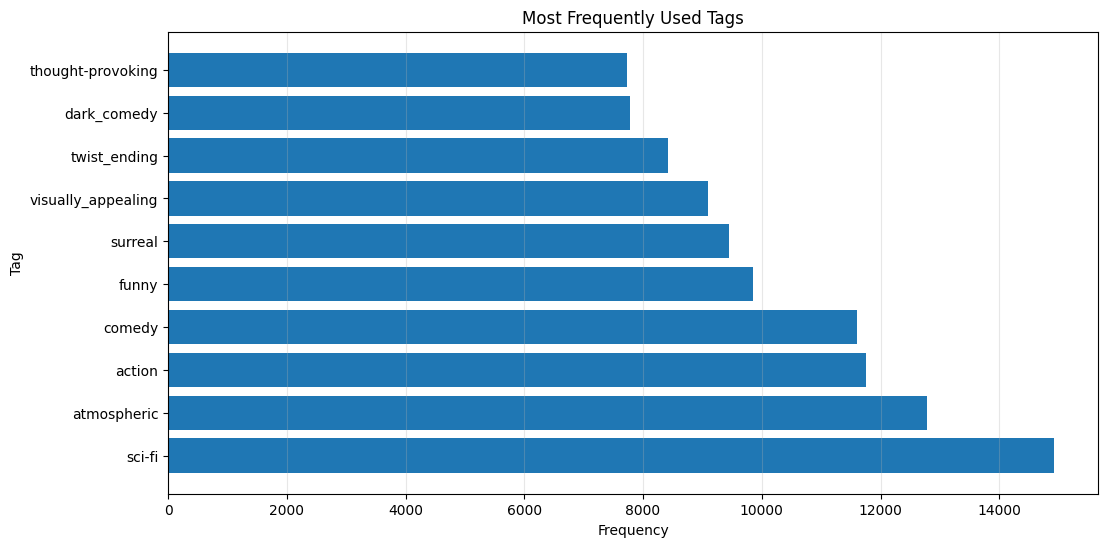

In [16]:
# 1. Which tags are used most frequently?
top_tags = (
    tags_df['tag']
    .value_counts()
    .sort_values(ascending= False)
    .head(10)
)
plt.figure(figsize=(12,6))
plt.barh(
    top_tags.index,
    top_tags.values
)
plt.title('Most Frequently Used Tags')
plt.xlabel('Frequency')
plt.ylabel('Tag')
plt.grid(axis='x', alpha=0.3)
plt.show()

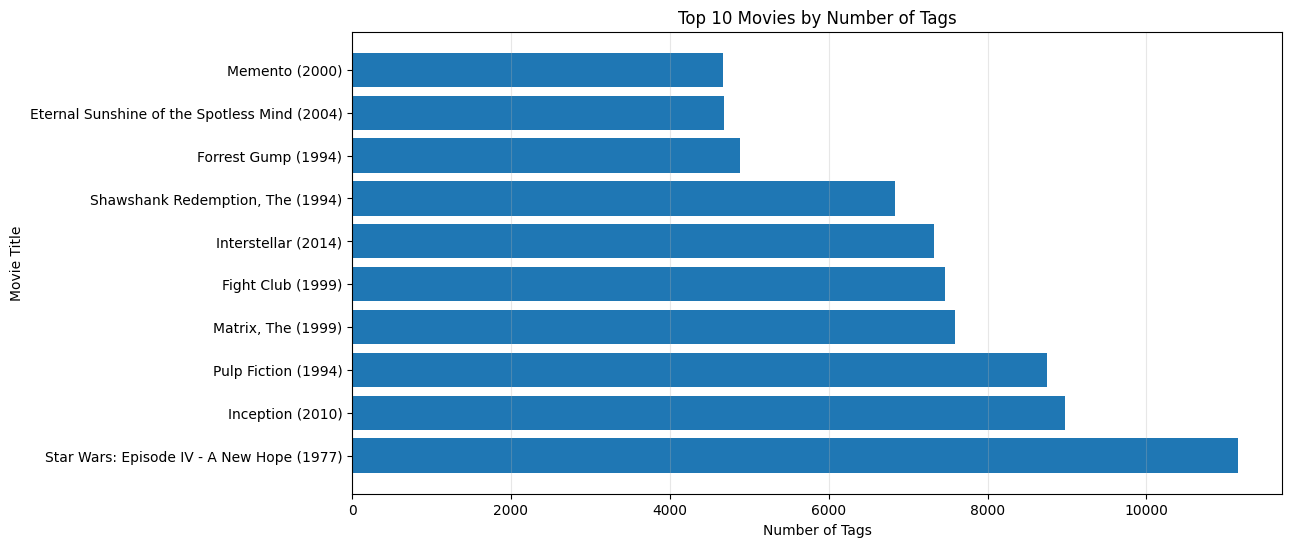

In [17]:
# Count tags per movie
movie_tag_counts = (
    tags_df.groupby('movieid')
    .size()
    .reset_index(name='tag_count')
)

# Merge movie titles
movie_tag_counts = movie_tag_counts.merge(
    movies_df[['movieid', 'title']],
    on='movieid'
)

# Top tagged movies
top_tagged_movies = movie_tag_counts.sort_values(
    by='tag_count',
    ascending=False
).head(10)

# plot
plt.figure(figsize=(12,6))
plt.barh(
    top_tagged_movies['title'],
    top_tagged_movies['tag_count']
)
plt.title('Top 10 Movies by Number of Tags')
plt.xlabel('Number of Tags')
plt.ylabel('Movie Title')
plt.grid(axis='x', alpha=0.3)
plt.show()

## RECOMMENDATION SYSTEM ANALYSIS

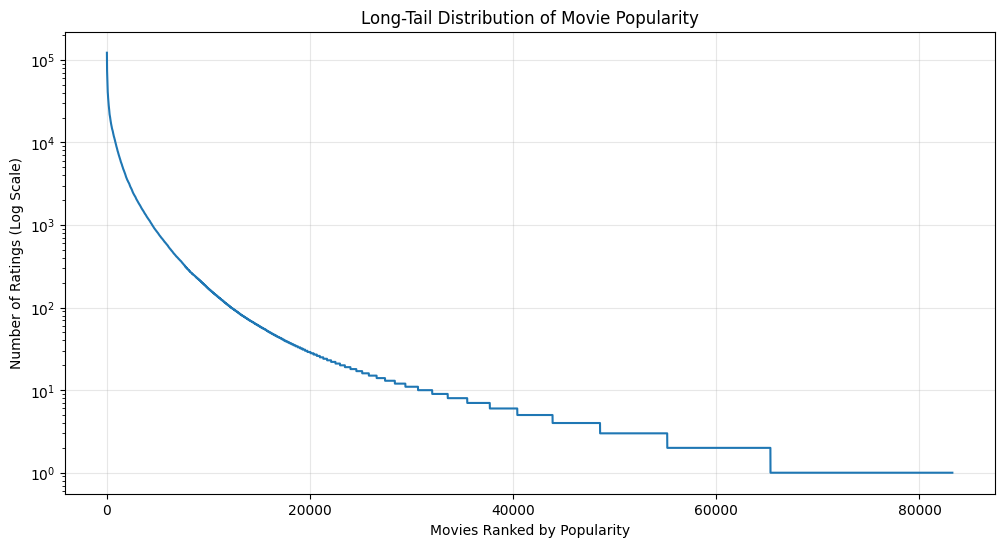

In [18]:
# Ratings count per movie
movie_rating_counts = (
    ratings_df.groupby('movieid')
    .size()
)
movie_rating_counts = movie_rating_counts.sort_values(
    ascending=False
)
# Plot
plt.figure(figsize=(12,6))
plt.plot(
    range(len(movie_rating_counts)),
    movie_rating_counts.values
)
# Log scale for better visibility
plt.yscale('log')
plt.title('Long-Tail Distribution of Movie Popularity')
plt.xlabel('Movies Ranked by Popularity')
plt.ylabel('Number of Ratings (Log Scale)')
plt.grid(alpha=0.3)
plt.show()

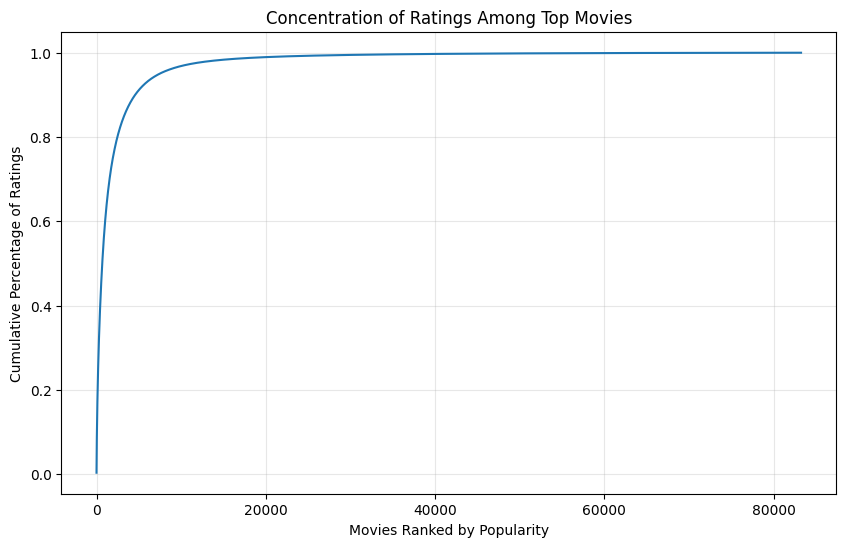

In [19]:
# Ratings count per movie
movie_rating_counts = (
    ratings_df.groupby('movieid')
    .size()
    .sort_values(ascending=False)
)
cumulative_ratings = (
    movie_rating_counts.cumsum()
    / movie_rating_counts.sum()
)
plt.figure(figsize=(10,6))
plt.plot(
    range(len(cumulative_ratings)),
    cumulative_ratings
)
plt.title('Concentration of Ratings Among Top Movies')
plt.xlabel('Movies Ranked by Popularity')
plt.ylabel('Cumulative Percentage of Ratings')
plt.grid(alpha=0.3)
plt.show()

## BIVARIATE ANALYSIS 

### MOVIE VS RATING ANALYSIS

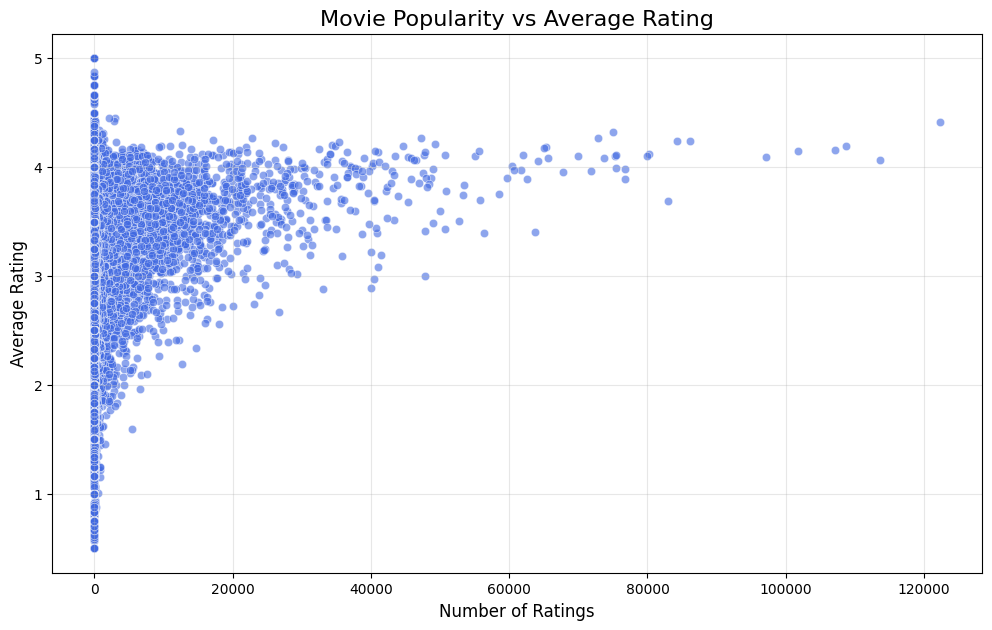

In [20]:
# Do movies with higher popularity also receive higher average ratings?

movie_stats = (
    ratings_df.groupby('movieid')
    .agg(
        average_rating=('rating', 'mean'),
        rating_count=('rating', 'count')
    )
    .reset_index()
)
# Merge movie titles
movie_stats = movie_stats.merge(
    movies_df[['movieid', 'title', 'release_year']],
    on='movieid'
)
# Scatter plot
plt.figure(figsize=(12,7))
sns.scatterplot(
    data=movie_stats,
    x='rating_count',
    y='average_rating',
    alpha=0.6,
    color='royalblue'
)
plt.title('Movie Popularity vs Average Rating', fontsize=16)
plt.xlabel('Number of Ratings', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

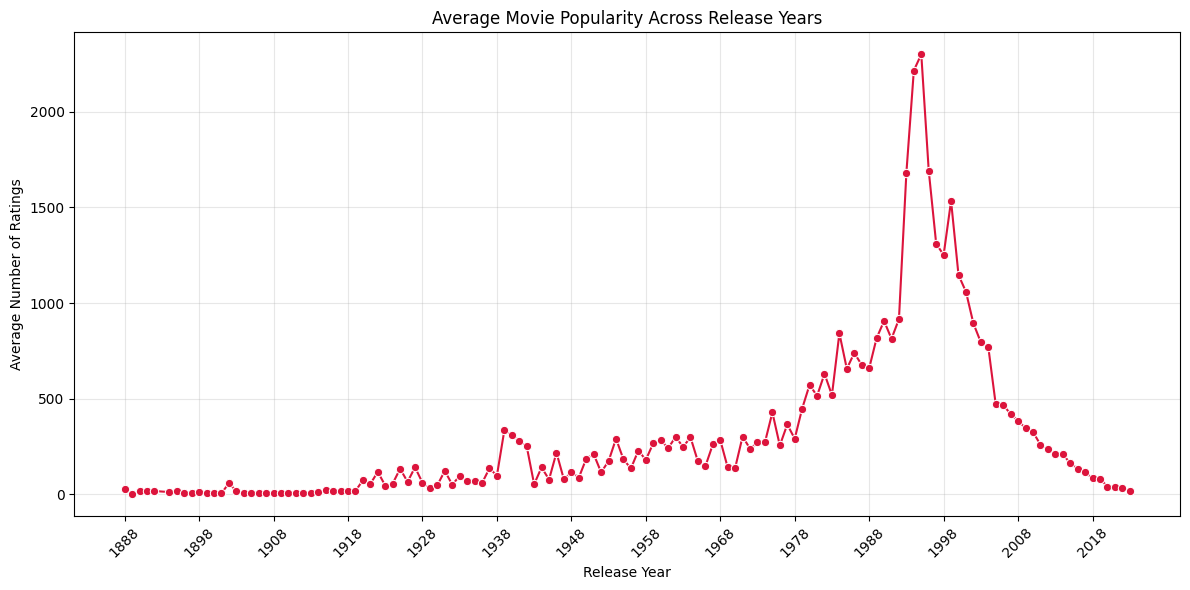

In [21]:
# How does movie popularity vary across release years?
# Create movie statistics
movie_stats = (
    ratings_df.groupby('movieid')
    .agg(
        average_rating=('rating', 'mean'),
        rating_count=('rating', 'count')
    )
    .reset_index()
)

# Remove invalid release years
movies_clean = movies_df[
    (movies_df['release_year'] >= 1888) &
    (movies_df['release_year'] <= 2025)
]

# Merge with movie information
movie_stats = movie_stats.merge(
    movies_clean[['movieid', 'title', 'release_year']],
    on='movieid',
    how='inner'
)

# Average popularity by release year
year_popularity = (
    movie_stats.groupby('release_year')['rating_count']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_popularity,
    x='release_year',
    y='rating_count',
    marker='o',
    color='crimson'
)

plt.title('Average Movie Popularity Across Release Years')
plt.xlabel('Release Year')
plt.ylabel('Average Number of Ratings')

# Better year formatting
plt.xticks(
    range(
        int(year_popularity['release_year'].min()),
        int(year_popularity['release_year'].max()) + 1,
        10
    ),
    rotation=45
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

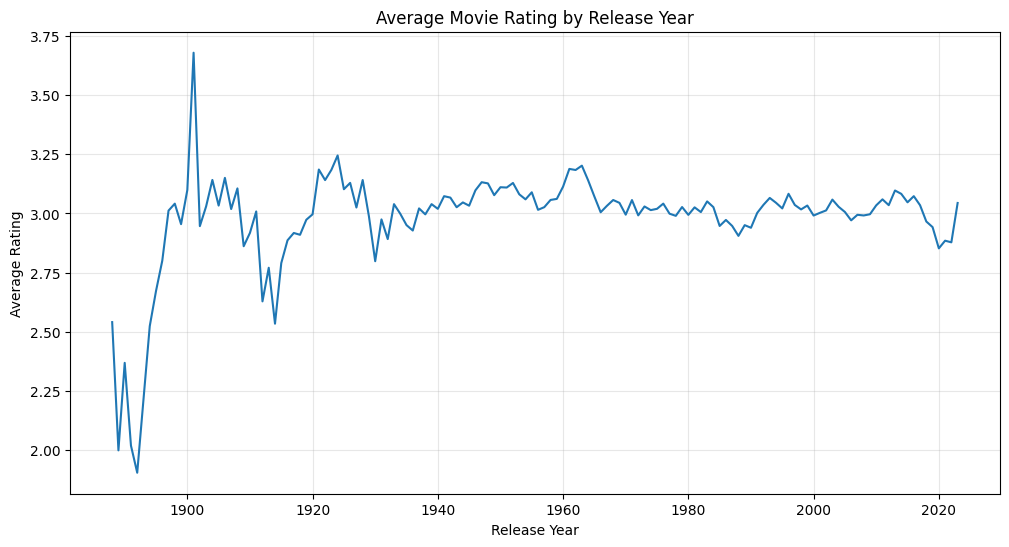

In [22]:
yearly_ratings = movie_stats.groupby('release_year')['average_rating'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=yearly_ratings,
    x='release_year',
    y='average_rating'
)

plt.title('Average Movie Rating by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Average Rating')
plt.grid(alpha=0.3)
plt.show()

In [23]:
# Which movies combine both high ratings and high engagement?
# Filter popular movies
top_movies = movie_stats[
    movie_stats['rating_count'] >= 1000
]

# Bubble chart
fig = px.scatter(
    top_movies,
    x='rating_count',
    y='average_rating',
    size='rating_count',
    hover_name='title',
    color='average_rating',
    color_continuous_scale='viridis',
    title='Highly Rated and Highly Popular Movies'
)

fig.update_layout(
    xaxis_title='Number of Ratings',
    yaxis_title='Average Rating',
    template='plotly_white'
)

fig.show()

### GENRE VS RATING ANALYSIS

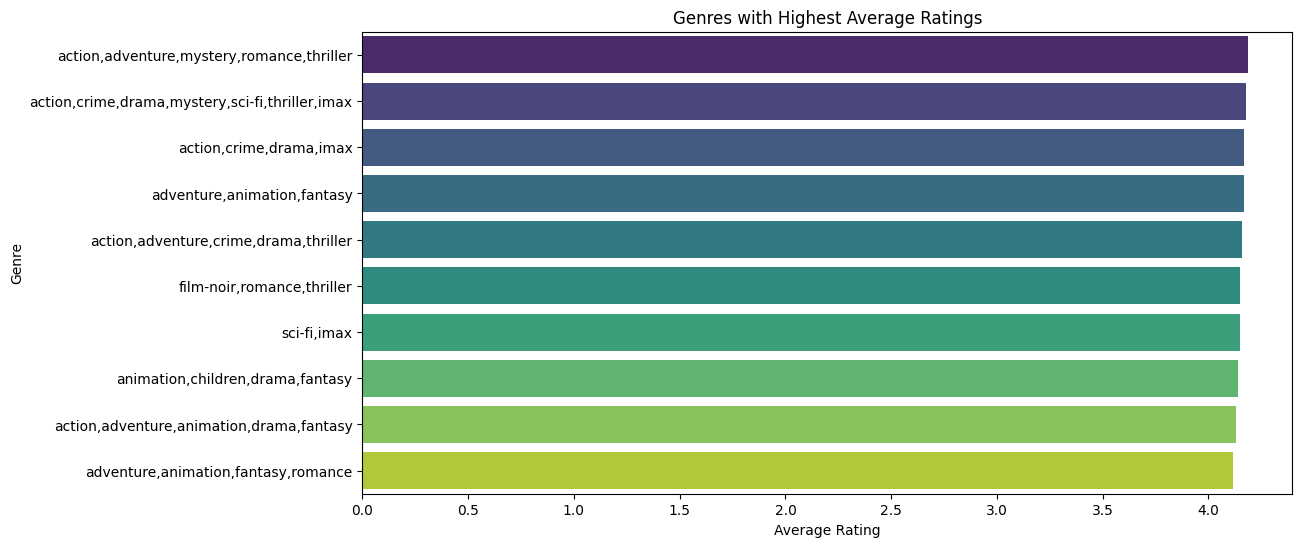

In [24]:
# Which genres receive the highest average ratings?
genre_ratings =(
    movies_df.merge(
        ratings_df,on='movieid'
    )
    .groupby('genres')
    .agg(
        avg_rating = ('rating','mean'),
        total_rating = ('rating','count')
    ).reset_index()
)
genre_ratings = genre_ratings[
    genre_ratings['total_rating'] >= 500
]
top_genres = genre_ratings.sort_values(
    by='avg_rating',
    ascending=False
).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_genres,
    x='avg_rating',
    y='genres',
    hue ='genres',
    palette='viridis'
)
plt.title('Genres with Highest Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()

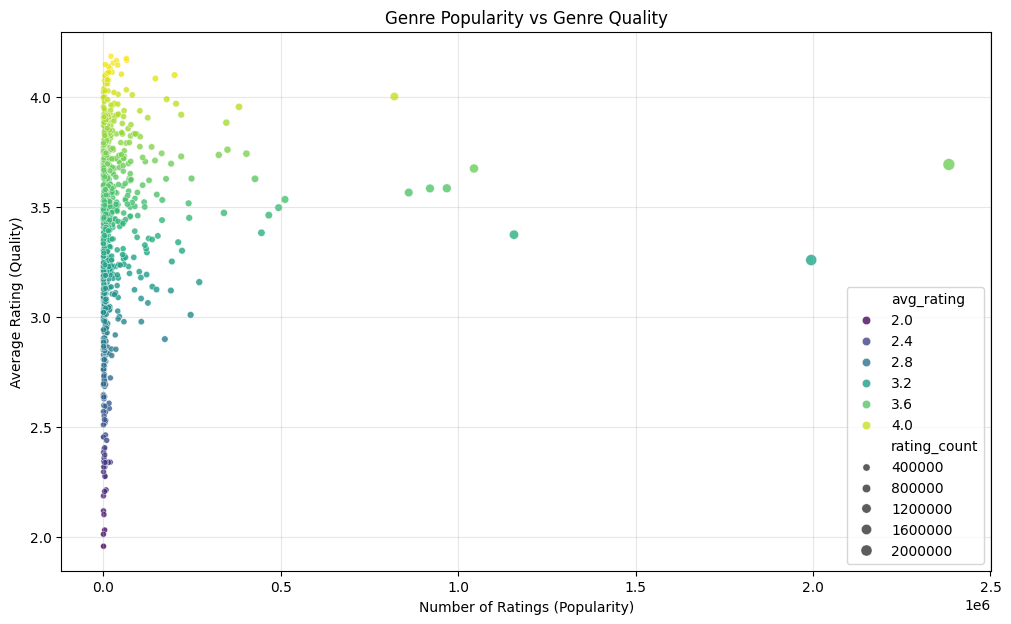

In [25]:
# Genre popularity vs quality
genre_stats = (
    movies_df
    .merge(ratings_df, on='movieid')
    .groupby('genres')
    .agg(
        avg_rating=('rating', 'mean'),
        rating_count=('rating', 'count')
    )
    .reset_index()
)

# Remove unknown genres
genre_stats = genre_stats[
    genre_stats['genres'] != 'unknown'
]

# Remove very small genres
genre_stats = genre_stats[
    genre_stats['rating_count'] >= 500
]

plt.figure(figsize=(12,7))

sns.scatterplot(
    data=genre_stats,
    x='rating_count',
    y='avg_rating',
    size='rating_count',
    hue='avg_rating',
    palette='viridis',
    alpha=0.8
)

plt.title('Genre Popularity vs Genre Quality')
plt.xlabel('Number of Ratings (Popularity)')
plt.ylabel('Average Rating (Quality)')

plt.grid(alpha=0.3)

plt.show()

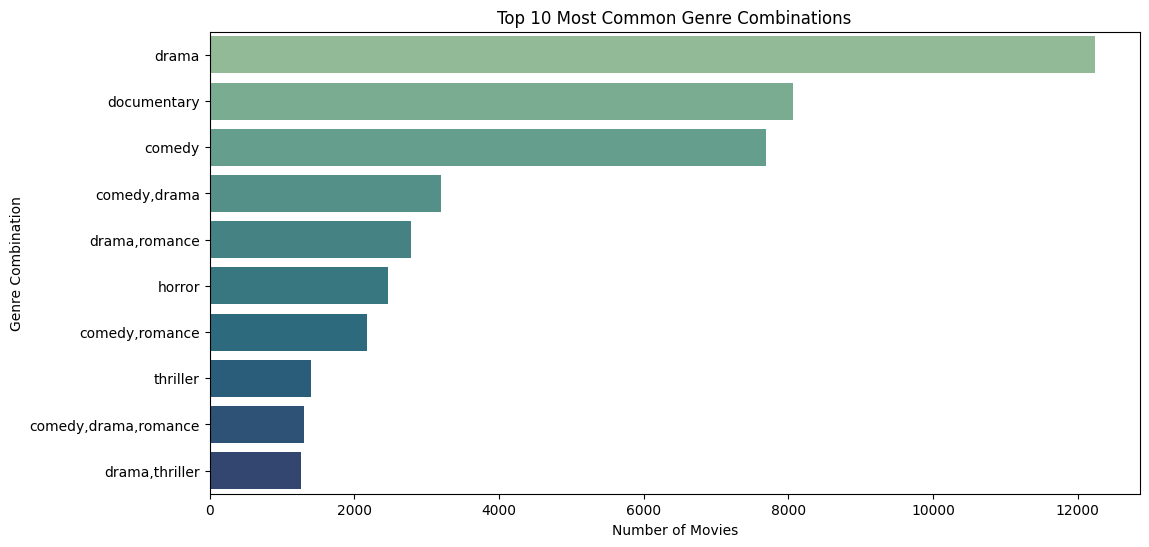

In [26]:
# Which genre combinations dominate the dataset?
# Genre combinations frequency
genre_combinations = (
    movies_df[
        movies_df['genres'] != 'unknown'
    ]['genres']
    .value_counts()
    .head(10)
)

# Convert to dataframe
genre_combinations = genre_combinations.reset_index()
genre_combinations.columns = ['genres', 'movie_count']

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    data=genre_combinations,
    x='movie_count',
    y='genres',
    hue='genres',
    palette='crest',
    legend=False
)

plt.title('Top 10 Most Common Genre Combinations')
plt.xlabel('Number of Movies')
plt.ylabel('Genre Combination')

plt.show()

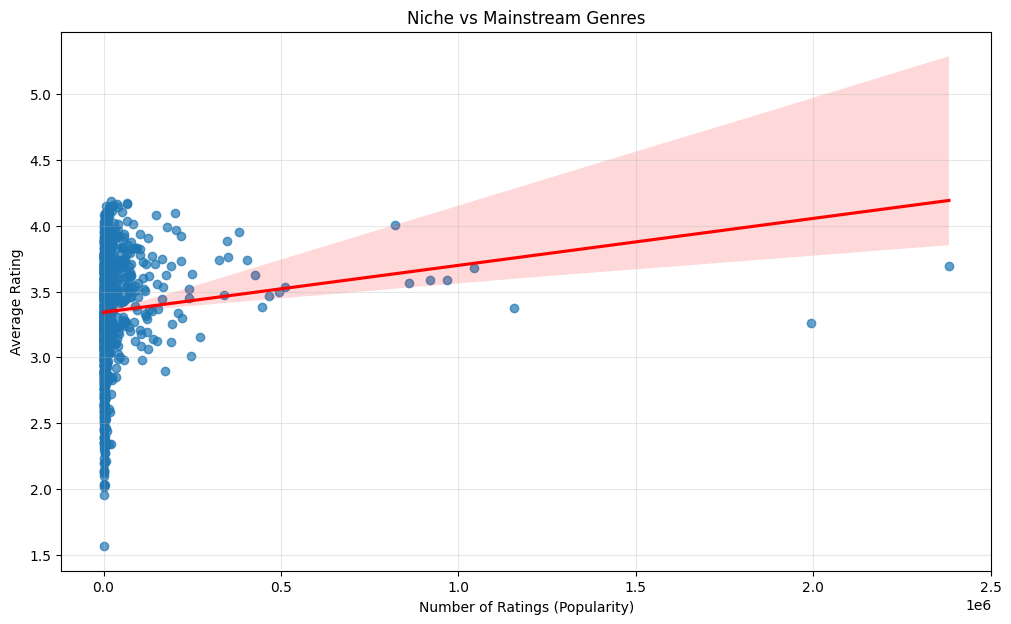

In [27]:
# Do niche genres receive higher ratings than mainstream genres?
# Genre statistics
genre_stats = (
    movies_df
    .merge(ratings_df, on='movieid')
    .groupby('genres')
    .agg(
        avg_rating=('rating', 'mean'),
        rating_count=('rating', 'count')
    )
    .reset_index()
)

# Remove unknown genres
genre_stats = genre_stats[
    genre_stats['genres'] != 'unknown'
]

# Remove tiny genres
genre_stats = genre_stats[
    genre_stats['rating_count'] >= 100
]

plt.figure(figsize=(12,7))

sns.regplot(
    data=genre_stats,
    x='rating_count',
    y='avg_rating',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red'}
)

plt.title('Niche vs Mainstream Genres')
plt.xlabel('Number of Ratings (Popularity)')
plt.ylabel('Average Rating')

plt.grid(alpha=0.3)

plt.show()

### USER BEHAVIOR ANALYSIS

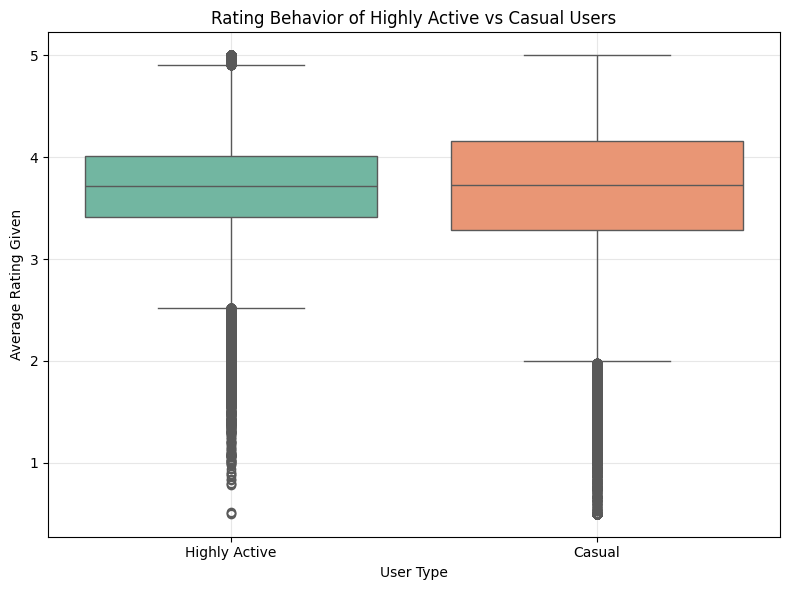

In [28]:
# User statistics
user_stats = (
    ratings_df.groupby('userid')
    .agg(
        avg_rating=('rating', 'mean'),
        rating_count=('rating', 'count')
    )
    .reset_index()
)

# Median split
median_count = user_stats['rating_count'].median()

user_stats['user_type'] = np.where(
    user_stats['rating_count'] >= median_count,
    'Highly Active',
    'Casual'
)

# Plot
plt.figure(figsize=(8,6))

sns.boxplot(
    data=user_stats,
    x='user_type',
    y='avg_rating',
    hue='user_type',
    palette='Set2',
    legend=False
)

plt.title('Rating Behavior of Highly Active vs Casual Users')
plt.xlabel('User Type')
plt.ylabel('Average Rating Given')

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

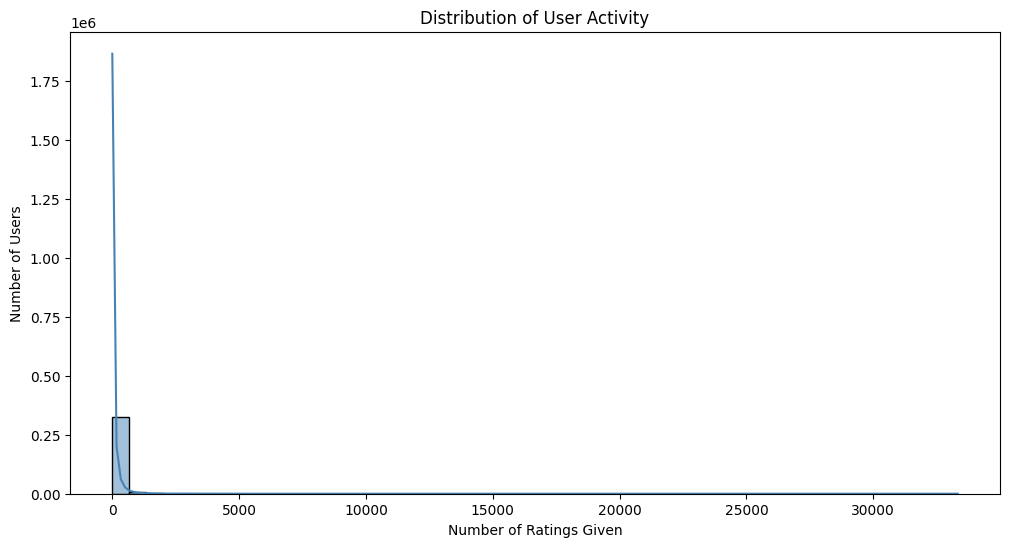

In [29]:
# How is user activity distributed across the dataset?
# Ratings per user
user_activity = (
    ratings_df.groupby('userid')
    .size()
)

# Plot
plt.figure(figsize=(12,6))

sns.histplot(
    user_activity,
    bins=50,
    kde=True,
    color='steelblue'
)

plt.title('Distribution of User Activity')
plt.xlabel('Number of Ratings Given')
plt.ylabel('Number of Users')

plt.show()

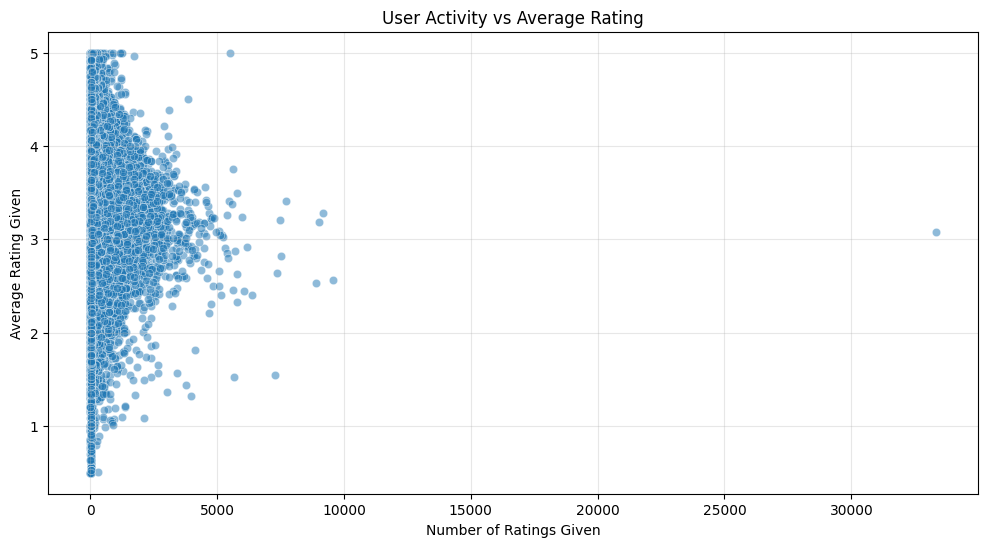

In [30]:
# Do users with high activity show rating bias?
# User statistics
user_stats = (
    ratings_df.groupby('userid')
    .agg(
        rating_count=('rating', 'count'),
        avg_rating=('rating', 'mean')
    )
    .reset_index()
)

# Remove users with very few ratings
user_stats = user_stats[
    user_stats['rating_count'] >= 10
]

# Plot
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=user_stats,
    x='rating_count',
    y='avg_rating',
    alpha=0.5
)

plt.title('User Activity vs Average Rating')
plt.xlabel('Number of Ratings Given')
plt.ylabel('Average Rating Given')

plt.grid(alpha=0.3)

plt.show()

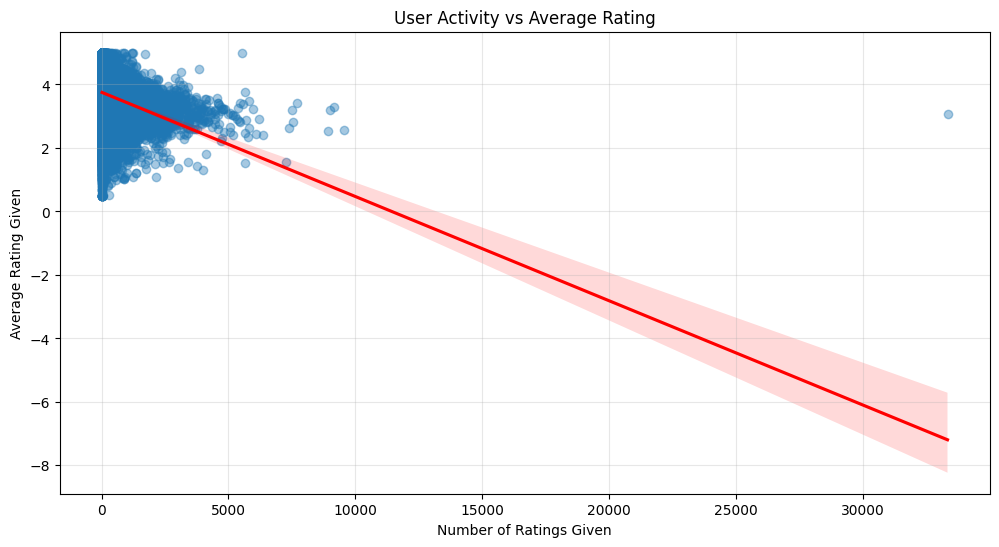

In [31]:
# Do users with high activity show rating bias?
# User statistics
user_stats = (
    ratings_df.groupby('userid')
    .agg(
        rating_count=('rating', 'count'),
        avg_rating=('rating', 'mean')
    )
    .reset_index()
)

# Keep users with enough ratings
user_stats = user_stats[
    user_stats['rating_count'] >= 20
]

plt.figure(figsize=(12,6))

sns.regplot(
    data=user_stats,
    x='rating_count',
    y='avg_rating',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red'}
)

plt.title('User Activity vs Average Rating')
plt.xlabel('Number of Ratings Given')
plt.ylabel('Average Rating Given')

plt.grid(alpha=0.3)

plt.show()


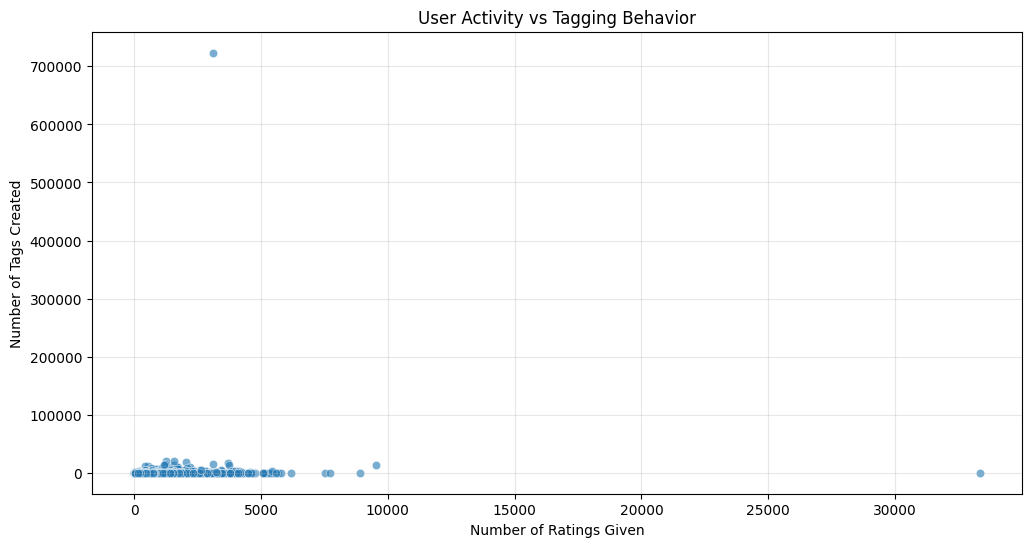

In [32]:
# What relationship exists between user activity and tagging behavior?
# Ratings per user
user_ratings = (
    ratings_df.groupby('userid')
    .size()
    .reset_index(name='rating_count')
)
# Tags per user
user_tags = (
    tags_df.groupby('userid')
    .size()
    .reset_index(name='tag_count')
)
# Merge
user_activity = user_ratings.merge(
    user_tags,
    on='userid',
    how='inner'
)
# Plot
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=user_activity,
    x='rating_count',
    y='tag_count',
    alpha=0.6
)

plt.title('User Activity vs Tagging Behavior')
plt.xlabel('Number of Ratings Given')
plt.ylabel('Number of Tags Created')

plt.grid(alpha=0.3)

plt.show()

### TIME-BASED ANALYSIS

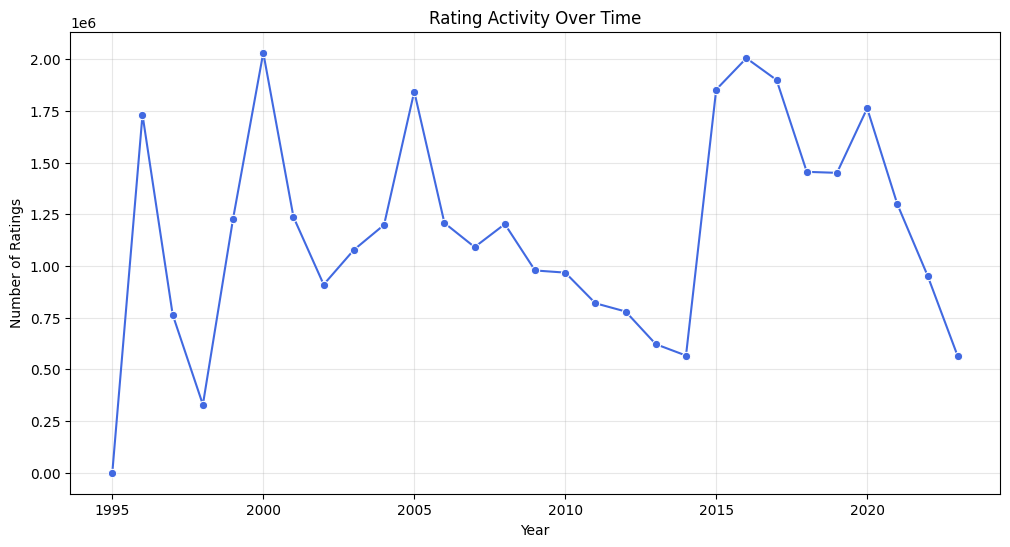

In [33]:
# Ratings per year
ratings_over_time = (
    ratings_df
    .groupby(ratings_df['rating_date'].dt.year)
    .size()
    .reset_index(name='total_ratings')
)

ratings_over_time.columns = [
    'rating_year',
    'total_ratings'
]

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=ratings_over_time,
    x='rating_year',
    y='total_ratings',
    marker='o',
    color='royalblue'
)

plt.title('Rating Activity Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Ratings')

plt.grid(alpha=0.3)

plt.show()

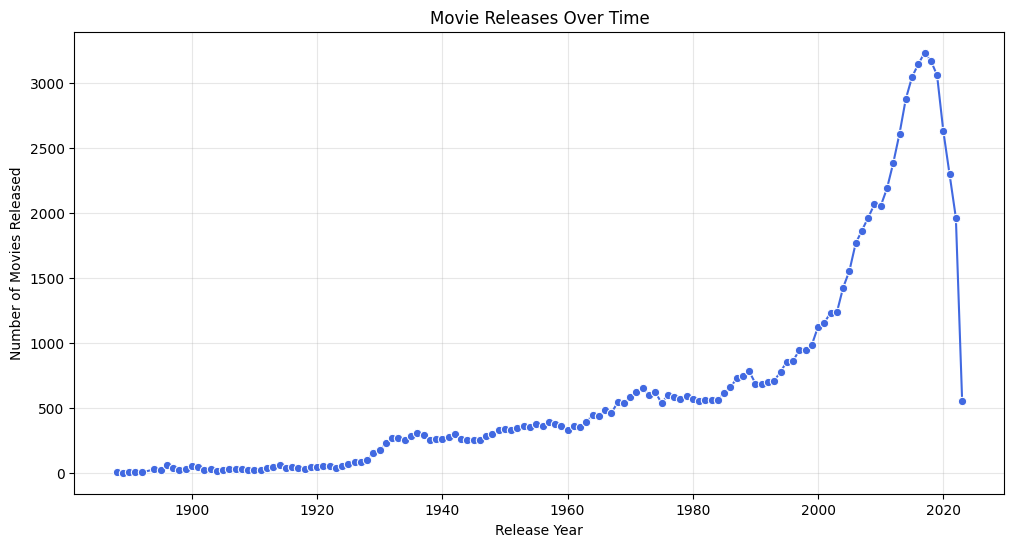

In [34]:
# How have movie releases changed over time?

# Remove invalid release years
movies_clean = movies_df[
    (movies_df['release_year'] >= 1888) &
    (movies_df['release_year'] <= 2025)
]

# Movies released per year
movies_per_year = (
    movies_clean.groupby('release_year')
    .size()
    .reset_index(name='movie_count')
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=movies_per_year,
    x='release_year',
    y='movie_count',
    marker='o',
    color='royalblue'
)

plt.title('Movie Releases Over Time')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies Released')

plt.grid(alpha=0.3)

plt.show()

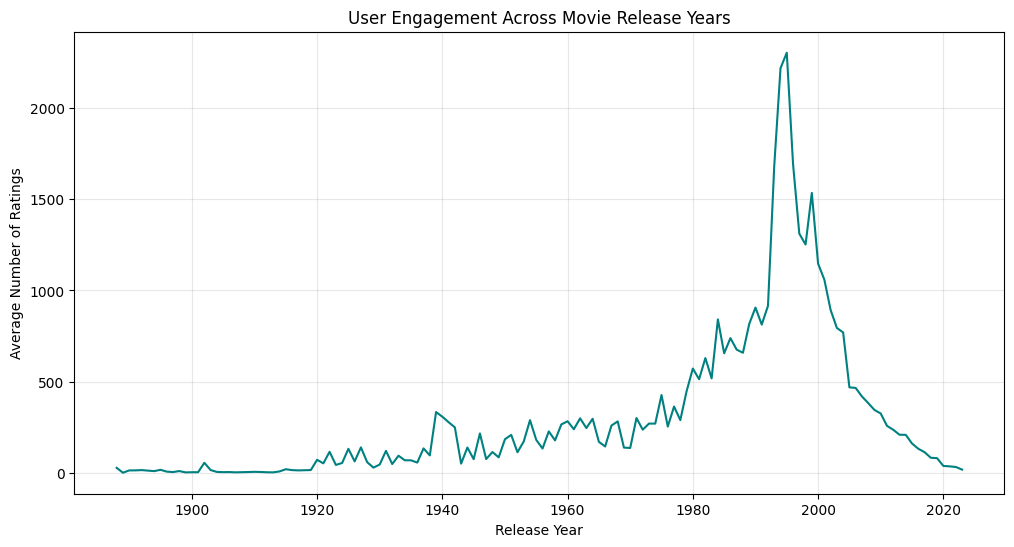

In [35]:
# Do newer movies receive more user engagement?

# Remove invalid release years
movies_clean = movies_df[
    (movies_df['release_year'] >= 1888) &
    (movies_df['release_year'] <= 2025)
]

# Ratings received by each movie
movie_engagement = (
    ratings_df.groupby('movieid')
    .size()
    .reset_index(name='rating_count')
)

# Merge release year
movie_engagement = movie_engagement.merge(
    movies_clean[['movieid', 'release_year']],
    on='movieid',
    how='inner'
)

# Average engagement by release year
year_engagement = (
    movie_engagement.groupby('release_year')['rating_count']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_engagement,
    x='release_year',
    y='rating_count',
    color='teal'
)

plt.title('User Engagement Across Movie Release Years')
plt.xlabel('Release Year')
plt.ylabel('Average Number of Ratings')
plt.grid(alpha=0.3)

plt.show()

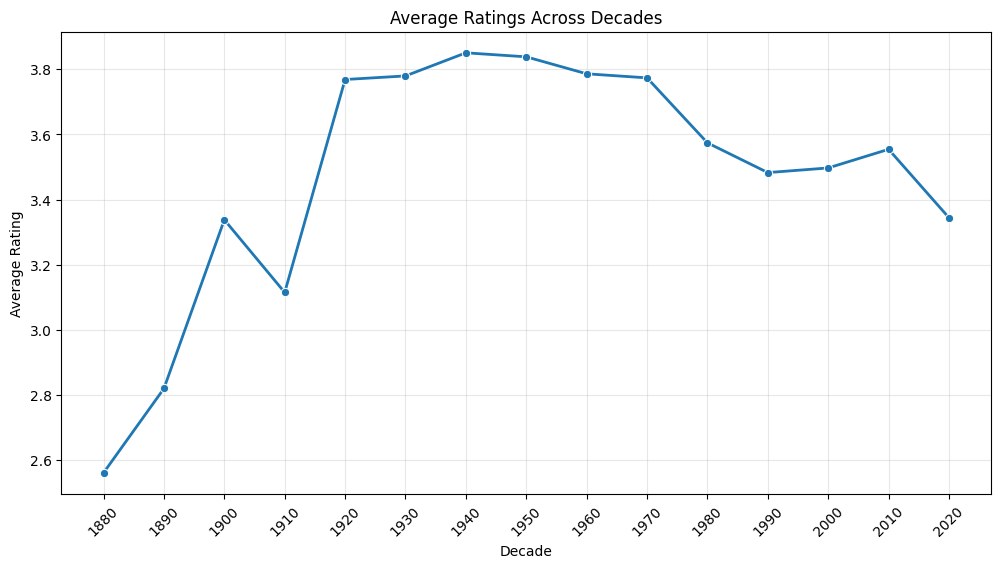

In [36]:
# How have average ratings changed over decades?

# Remove invalid ratings
ratings_clean = ratings_df[
    ratings_df['rating'] >= 0
]

# Remove invalid release years
movies_clean = movies_df[
    (movies_df['release_year'] >= 1888) &
    (movies_df['release_year'] <= 2025)
]

# Merge ratings with movie release years
movie_ratings = ratings_clean.merge(
    movies_clean[['movieid', 'release_year']],
    on='movieid',
    how='inner'
)

# Create decade column
movie_ratings['decade'] = (
    movie_ratings['release_year'] // 10
) * 10

# Calculate average rating by decade
avg_rating_by_decade = (
    movie_ratings.groupby('decade')['rating']
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=avg_rating_by_decade,
    x='decade',
    y='rating',
    marker='o',
    linewidth=2
)

plt.title('Average Ratings Across Decades')
plt.xlabel('Decade')
plt.ylabel('Average Rating')
plt.xticks(avg_rating_by_decade['decade'], rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

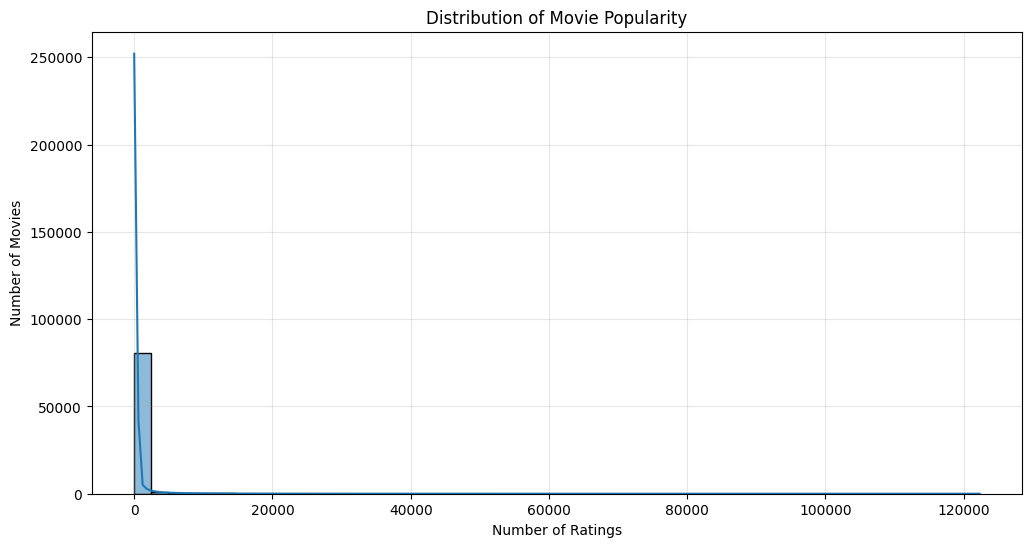

In [37]:
# How does movie popularity follow a long-tail distribution?
# Number of ratings per movie
movie_popularity = (
    ratings_df.groupby('movieid')
    .size()
    .reset_index(name='rating_count')
)

plt.figure(figsize=(12,6))

sns.histplot(
    movie_popularity['rating_count'],
    bins=50,
    kde=True
)

plt.title('Distribution of Movie Popularity')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')

plt.grid(alpha=0.3)
plt.show()

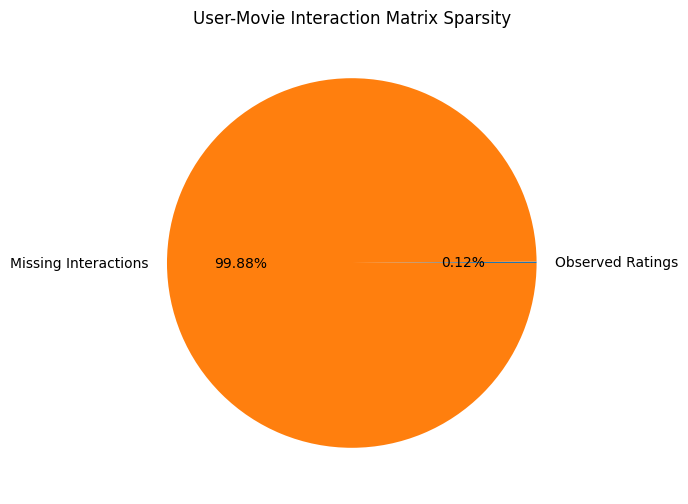

In [38]:
# How sparse is the user-movie interaction matrix?
num_users = ratings_df['userid'].nunique()
num_movies = ratings_df['movieid'].nunique()

actual_ratings = len(ratings_df)

possible_interactions = num_users * num_movies

sparsity = (
    1 - (actual_ratings / possible_interactions)
) * 100



filled = actual_ratings
empty = possible_interactions - actual_ratings

plt.figure(figsize=(6,6))

plt.pie(
    [filled, empty],
    labels=['Observed Ratings', 'Missing Interactions'],
    autopct='%1.2f%%'
)

plt.title('User-Movie Interaction Matrix Sparsity')
plt.show()

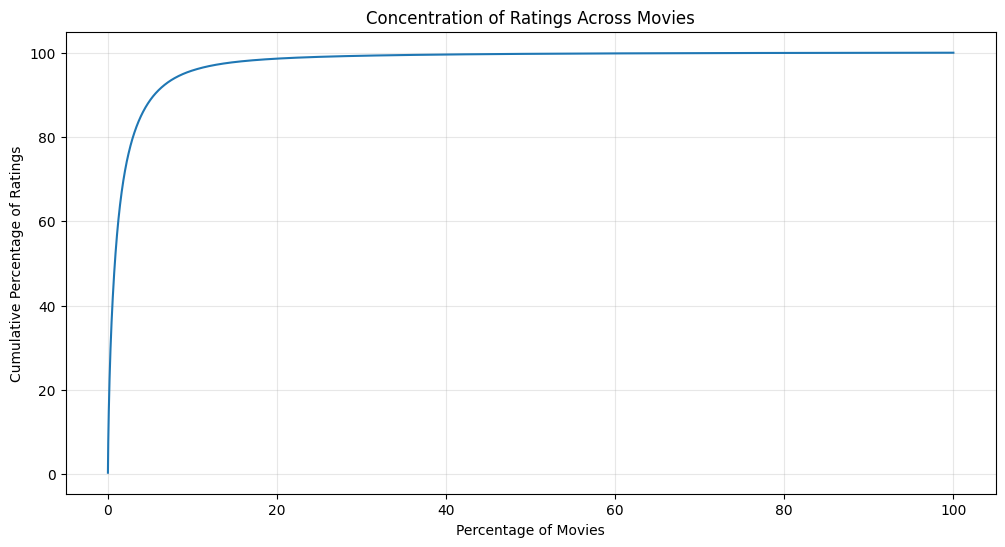

In [39]:
# Do a small number of movies receive most ratings?

# Ratings received by each movie
movie_popularity = (
    ratings_df.groupby('movieid')
    .size()
    .reset_index(name='rating_count')
)

# Sort by popularity
movie_popularity = movie_popularity.sort_values(
    by='rating_count',
    ascending=False
).reset_index(drop=True)

# Cumulative percentage of ratings
movie_popularity['cumulative_ratings'] = (
    movie_popularity['rating_count'].cumsum()
)

movie_popularity['cumulative_percentage'] = (
    movie_popularity['cumulative_ratings']
    / movie_popularity['rating_count'].sum()
) * 100

movie_popularity['movie_percentage'] = (
    (movie_popularity.index + 1)
    / len(movie_popularity)
) * 100

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=movie_popularity,
    x='movie_percentage',
    y='cumulative_percentage'
)

plt.title('Concentration of Ratings Across Movies')
plt.xlabel('Percentage of Movies')
plt.ylabel('Cumulative Percentage of Ratings')
plt.grid(alpha=0.3)

plt.show()